In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_PATH = Path("..")
DATA_PATH = PROJECT_PATH / "data" / "raw"

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

In [2]:
import matplotlib.ticker as ticker

In [3]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [6]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [7]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()
print("Delivered orders:", delivered_orders["order_id"].nunique())

Delivered orders: 96478


In [8]:
sales = delivered_orders.merge(order_items, on="order_id", how="inner")

print("Sales rows:", len(sales))
print("Unique orders:", sales["order_id"].nunique())

Sales rows: 110197
Unique orders: 96478


In [9]:
total_revenue = sales["price"].sum()
total_orders = sales["order_id"].nunique()
total_items = len(sales)
average_order_value = total_revenue / total_orders
total_freight = sales["freight_value"].sum()

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Items Sold: {total_items:,}")
print(f"Average Order Value: R$ {average_order_value:,.2f}")
print(f"Total Freight: R$ {total_freight:,.2f}")

Total Revenue: R$ 13,221,498.11
Total Orders: 96,478
Total Items Sold: 110,197
Average Order Value: R$ 137.04
Total Freight: R$ 2,198,275.64


In [10]:
freight_percentage = (total_freight / total_revenue) * 100
print(f"Freight as % of Revenue: {freight_percentage:.2f}%")

Freight as % of Revenue: 16.63%


## Sales Analysis

In [11]:
# Monthly Revenue
monthly_revenue = (sales.groupby(sales["order_purchase_timestamp"].dt.to_period("M"))["price"].sum())
monthly_revenue

order_purchase_timestamp
2016-09       134.97
2016-10     40325.11
2016-12        10.90
2017-01    111798.36
2017-02    234223.40
2017-03    359198.85
2017-04    340669.68
2017-05    489338.25
2017-06    421923.37
2017-07    481604.52
2017-08    554699.70
2017-09    607399.67
2017-10    648247.65
2017-11    987765.37
2017-12    726033.19
2018-01    924645.00
2018-02    826437.13
2018-03    953356.25
2018-04    973534.09
2018-05    977544.69
2018-06    856077.86
2018-07    867953.46
2018-08    838576.64
Freq: M, Name: price, dtype: float64

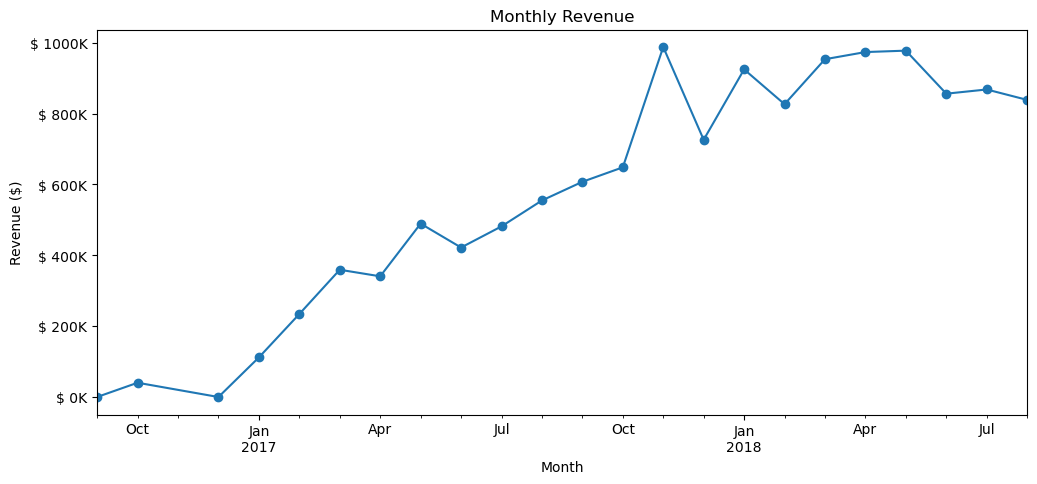

In [12]:
monthly_revenue.plot(figsize=(12, 5), marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"$ {x/1000:.0f}K"))
plt.show()

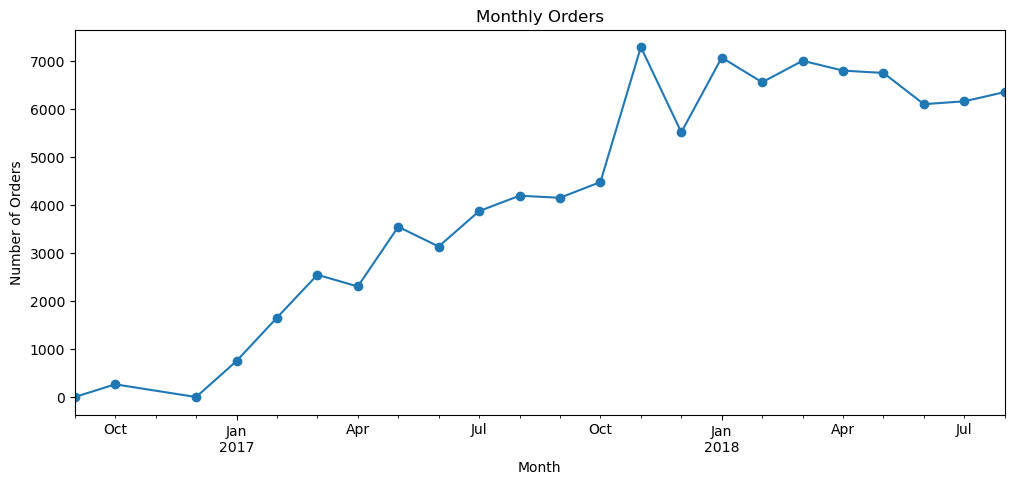

In [13]:
# Monthly orders
monthly_orders = ( sales.groupby(sales["order_purchase_timestamp"].dt.to_period("M"))["order_id"].nunique() )

monthly_orders.plot(figsize=(12, 5), marker="o")
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

- Monthly Revenue and Monthly Orders trend are similar, that can mean that revenue movement and order volume move hand in hand.
- But, we need to investigate the trend of customer's spending per order (Average Order Value, AOV).
- If revenue and orders move together and AOV is stable, then the growth volume-driven growth. If revenue and AOV move together and orders is stable, then growth is driven by higher customer spend. If revenue, orders and AOV all move together, then both are driving growth.

In [14]:
monthly_sales = (sales.groupby(sales["order_purchase_timestamp"].dt.to_period("M")).agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique")
    )
)

monthly_sales["aov"] = (monthly_sales["revenue"] / monthly_sales["orders"])

In [15]:
monthly_sales

,revenue,orders,aov
order_purchase_timestamp,,,
2016-09,134.97,1,134.970000
2016-10,40325.11,265,152.170226
2016-12,10.90,1,10.900000
2017-01,111798.36,750,149.064480
2017-02,234223.40,1653,141.695947
2017-03,359198.85,2546,141.083602
2017-04,340669.68,2303,147.924307
2017-05,489338.25,3546,137.997250
2017-06,421923.37,3135,134.584807


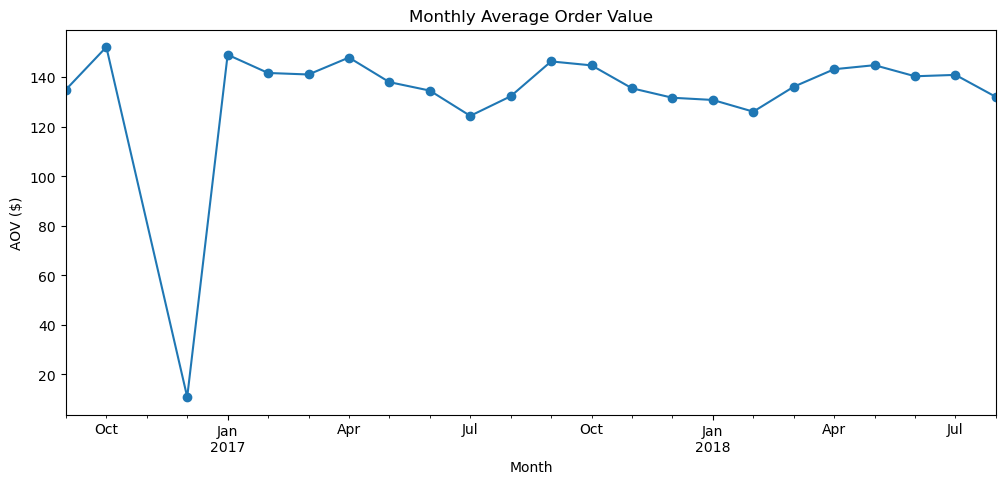

In [16]:
monthly_sales["aov"].plot(figsize=(12, 5), marker="o")

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("AOV ($)")
plt.xticks(rotation=0)
plt.show()

Since, AOV trend is quite stable relative to Revenue, then the initial hypothesis is Revenue fluctuations are primarily driven by changes in the number of orders rather than major changes in spending per order.

## Category Performance

In [17]:
sales_products = sales.merge(products[["product_id", "product_category_name"]], on="product_id",how="left")
print("Rows:", len(sales_products))

Rows: 110197


In [18]:
sales_products = sales_products.merge(category_translation, on="product_category_name", how="left")

sales_products[ ["product_category_name", "product_category_name_english"]].head()

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


In [19]:
category_revenue = (sales_products.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False))

category_revenue.head(15)

product_category_name_english
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
garden_tools              470495.28
baby                      400421.84
perfumery                 390144.65
telephony                 309860.23
office_furniture          268154.31
Name: price, dtype: float64

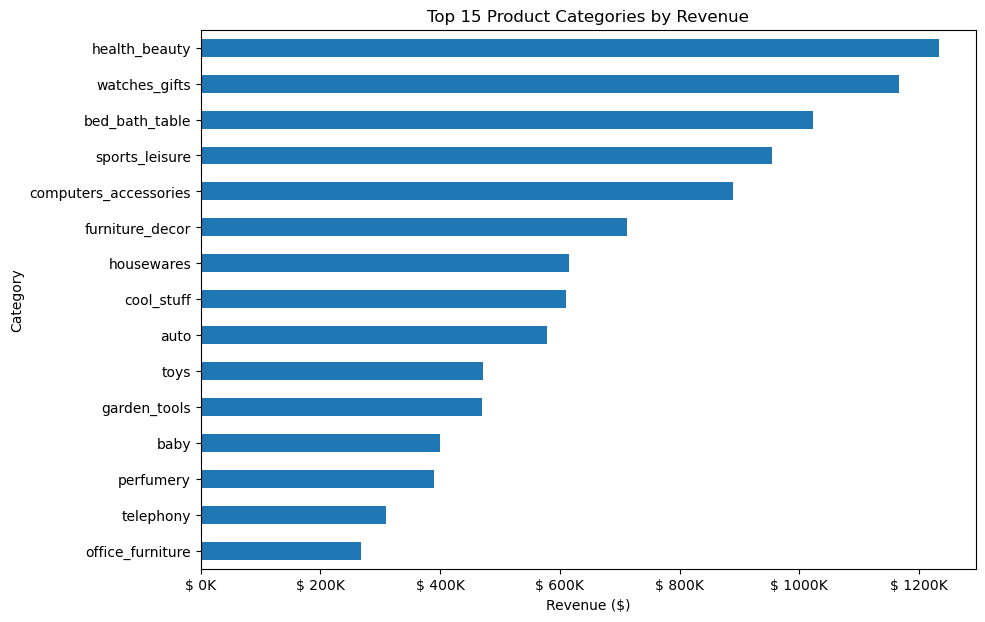

In [20]:
category_revenue.head(15).sort_values().plot(kind="barh",figsize=(10, 7))

plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Category")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"$ {x/1000:.0f}K"))

plt.show()

In [21]:
# Category-wise orders and revenue
category_performance = (
    sales_products.groupby("product_category_name_english").agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("product_id", "count")
    ).sort_values("revenue", ascending=False)
)
category_performance.head(15)

,revenue,orders,items_sold
product_category_name_english,,,
health_beauty,1233131.72,8647,9465
watches_gifts,1166176.98,5495,5859
bed_bath_table,1023434.76,9272,10953
sports_leisure,954852.55,7530,8431
computers_accessories,888724.61,6530,7644
furniture_decor,711927.69,6307,8160
housewares,615628.69,5743,6795
cool_stuff,610204.10,3559,3718
auto,578966.65,3810,4140


In [22]:
# category share of revenue
category_performance["revenue_share"] = (category_performance["revenue"] / total_revenue) * 100
category_performance.head(15)

,revenue,orders,items_sold,revenue_share
product_category_name_english,,,,
health_beauty,1233131.72,8647,9465,9.326717
watches_gifts,1166176.98,5495,5859,8.820309
bed_bath_table,1023434.76,9272,10953,7.740687
sports_leisure,954852.55,7530,8431,7.221969
computers_accessories,888724.61,6530,7644,6.721815
furniture_decor,711927.69,6307,8160,5.384622
housewares,615628.69,5743,6795,4.656270
cool_stuff,610204.10,3559,3718,4.615242
auto,578966.65,3810,4140,4.378979


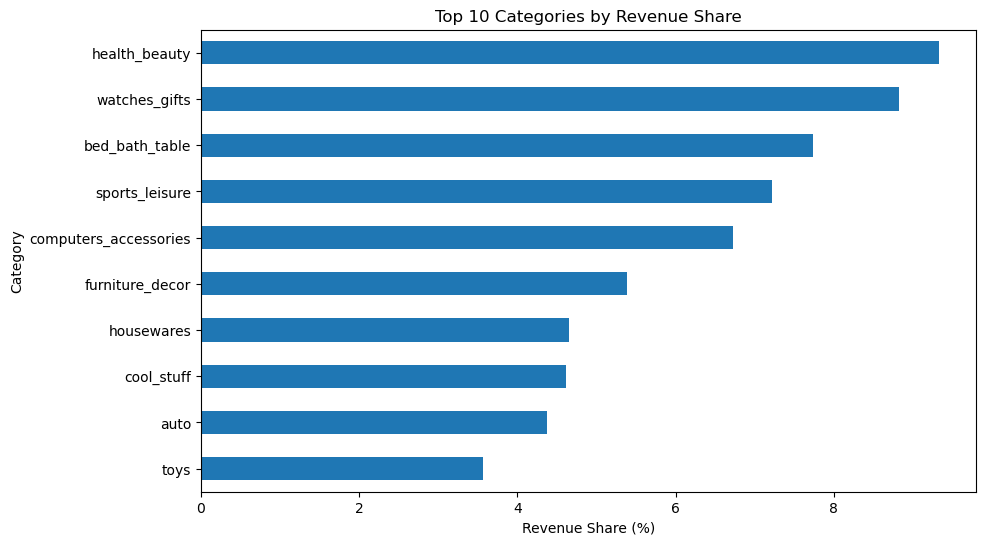

In [23]:
# Top categories by revenue share
top_categories = category_performance.head(10).sort_values("revenue_share")

top_categories["revenue_share"].plot(kind="barh", figsize=(10, 6) )
plt.title("Top 10 Categories by Revenue Share")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Category")

plt.show()

In [24]:
missing_category = sales_products[sales_products["product_category_name_english"].isna()]

print("Items with missing category:", len(missing_category))
print("Revenue from missing categories:", missing_category["price"].sum() )

Items with missing category: 1559
Revenue from missing categories: 175967.21000000002


In [25]:
missing_revenue_share = (missing_category["price"].sum() / total_revenue) * 100
print(f"Missing-category revenue share: {missing_revenue_share:.2f}%")

Missing-category revenue share: 1.33%


In [26]:
# orders by category
category_orders = (category_performance.sort_values("orders", ascending=False))
category_orders.head(15)

,revenue,orders,items_sold,revenue_share
product_category_name_english,,,,
bed_bath_table,1023434.76,9272,10953,7.740687
health_beauty,1233131.72,8647,9465,9.326717
sports_leisure,954852.55,7530,8431,7.221969
computers_accessories,888724.61,6530,7644,6.721815
furniture_decor,711927.69,6307,8160,5.384622
housewares,615628.69,5743,6795,4.656270
watches_gifts,1166176.98,5495,5859,8.820309
telephony,309860.23,4093,4430,2.343609
auto,578966.65,3810,4140,4.378979


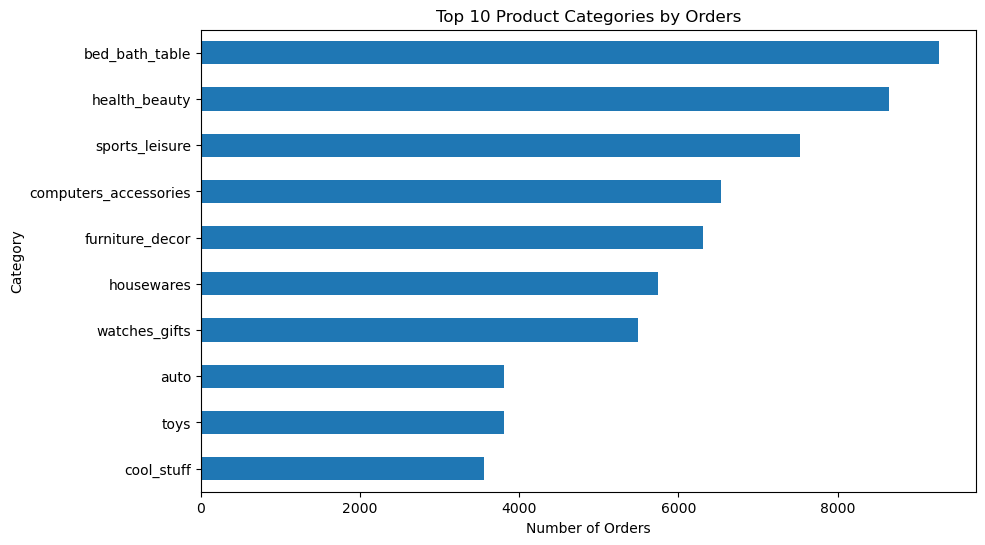

In [27]:
category_orders = category_performance.head(10).sort_values("orders")
category_orders["orders"].plot(kind="barh", figsize=(10, 6) )

plt.title("Top 10 Product Categories by Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.show()

In [28]:
# Revenue per order by category
category_performance["revenue_per_order"] = (category_performance["revenue"] / category_performance["orders"])

category_performance.sort_values("revenue_per_order", ascending=False).head(15)

,revenue,orders,items_sold,revenue_share,revenue_per_order
product_category_name_english,,,,,
computers,218684.14,177,199,1.654004,1235.503616
small_appliances_home_oven_and_coffee,46589.56,72,73,0.352377,647.077222
home_appliances_2,107953.95,227,231,0.816503,475.568062
agro_industry_and_commerce,70566.10,177,206,0.533722,398.678531
musical_instruments,184315.74,611,651,1.394061,301.662422
small_appliances,182754.12,609,658,1.382250,300.088867
fixed_telephony,55315.21,212,255,0.418373,260.920802
construction_tools_safety,38773.22,159,183,0.293259,243.856730
air_conditioning,53323.56,246,289,0.403310,216.762439


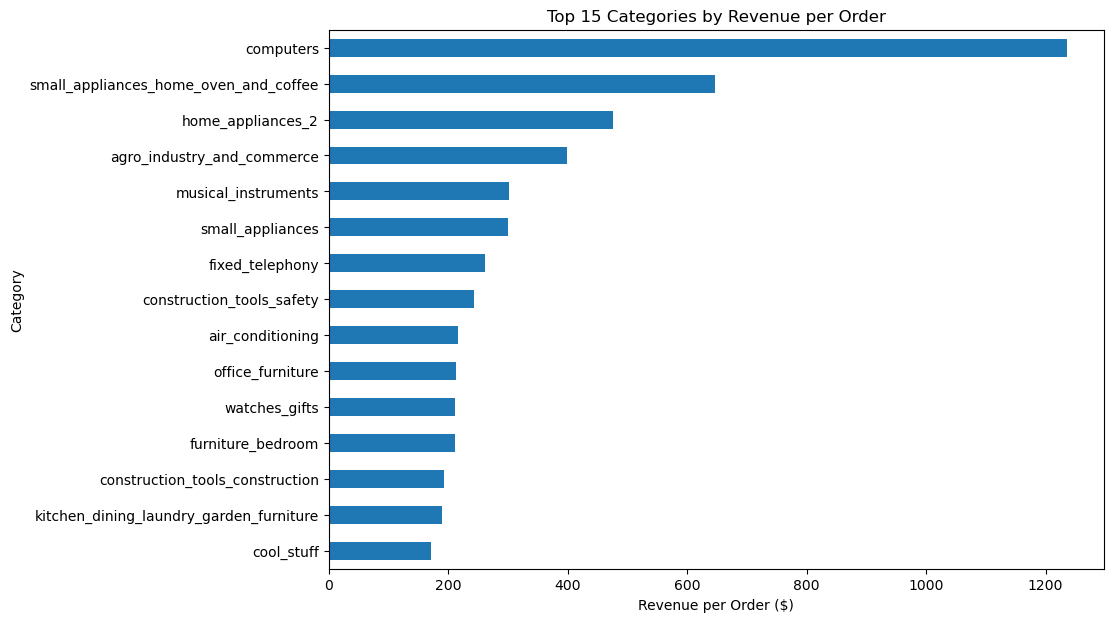

In [29]:
category_performance.sort_values(
    "revenue_per_order", ascending=False).head(15).sort_values("revenue_per_order")["revenue_per_order"].plot(
    kind="barh",
    figsize=(10, 7) )

plt.title("Top 15 Categories by Revenue per Order")
plt.xlabel("Revenue per Order ($)")
plt.ylabel("Category")

plt.show()

## Product Performance

In [30]:
product_performance = (sales_products.groupby(["product_id", "product_category_name_english" ]).agg(
        revenue=("price", "sum"),
        items_sold=("product_id", "count"),
        orders=("order_id", "nunique")
    )    .sort_values("revenue", ascending=False)
)
product_performance.head(15)

,,revenue,items_sold,orders
product_id,product_category_name_english,,,
bb50f2e236e5eea0100680137654686c,health_beauty,63560.00,194,186
6cdd53843498f92890544667809f1595,health_beauty,53652.30,153,148
d6160fb7873f184099d9bc95e30376af,computers,45949.35,33,33
d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,45620.56,332,313
99a4788cb24856965c36a24e339b6058,bed_bath_table,42049.66,477,456
3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,40782.80,272,253
25c38557cf793876c5abdd5931f922db,baby,38907.32,38,38
5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,37733.90,63,63
53b36df67ebb7c41585e8d54d6772e08,watches_gifts,37454.63,321,304


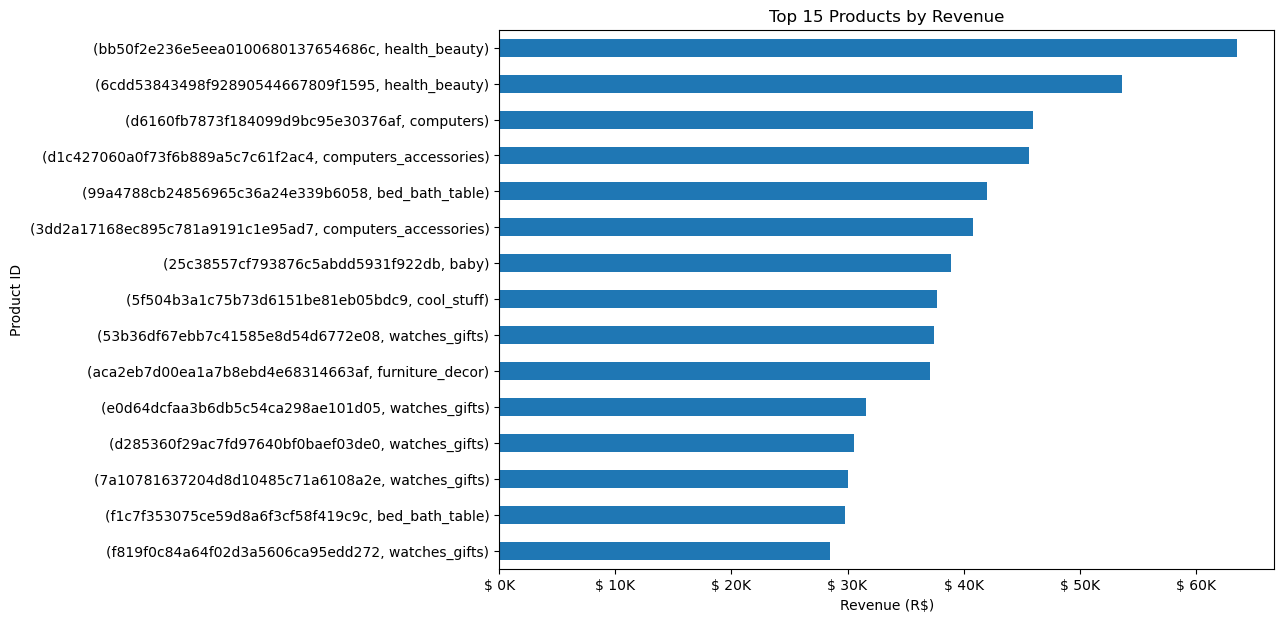

In [31]:
# Top 15 products by revenue
top_products = product_performance.head(15).sort_values("revenue")

top_products["revenue"].plot(kind="barh", figsize=(10, 7))

plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Product ID")

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"$ {x/1000:.0f}K"))

plt.show()

In [32]:
# Most frequently sold products
top_volume_products = (product_performance.sort_values("items_sold", ascending=False).head(15))
top_volume_products

,,revenue,items_sold,orders
product_id,product_category_name_english,,,
aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,37104.30,520,425
422879e10f46682990de24d770e7f83d,garden_tools,26577.22,484,352
99a4788cb24856965c36a24e339b6058,bed_bath_table,42049.66,477,456
389d119b48cf3043d311335e499d9c6b,garden_tools,21336.79,390,309
368c6c730842d78016ad823897a372db,garden_tools,21056.80,388,291
53759a2ecddad2bb87a079a1f1519f73,garden_tools,20387.20,373,287
d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,45620.56,332,313
53b36df67ebb7c41585e8d54d6772e08,watches_gifts,37454.63,321,304
154e7e31ebfa092203795c972e5804a6,health_beauty,6173.26,274,262


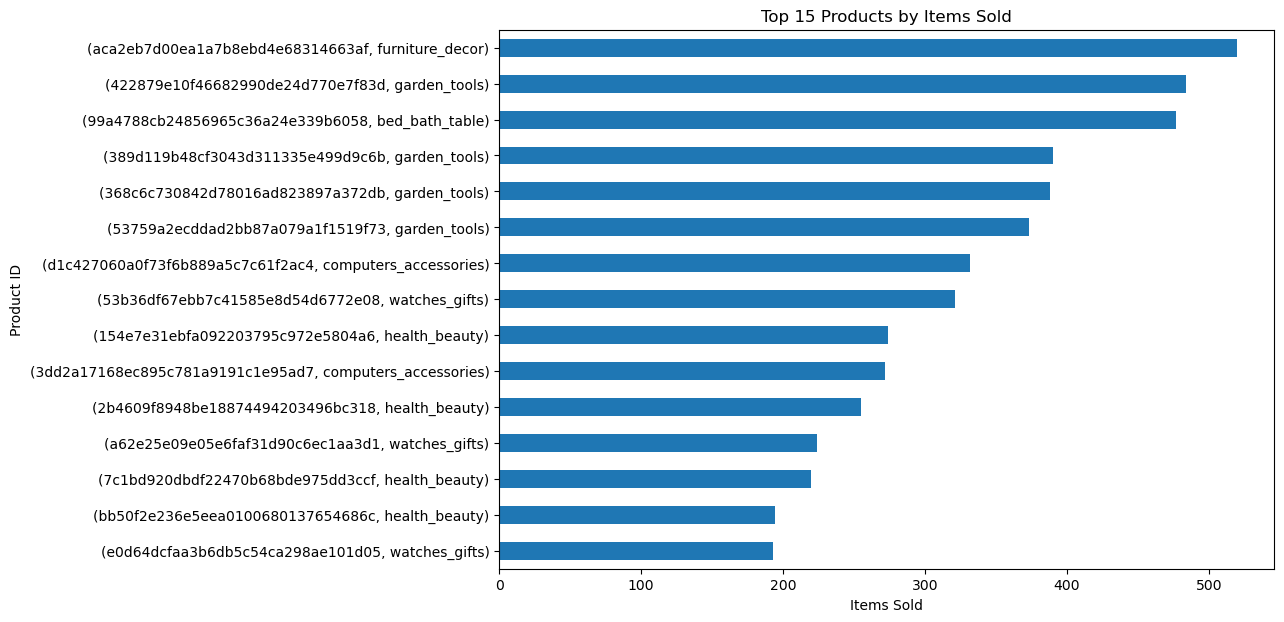

In [33]:
top_volume_products.sort_values("items_sold")["items_sold"].plot(kind="barh", figsize=(10, 7))

plt.title("Top 15 Products by Items Sold")
plt.xlabel("Items Sold")
plt.ylabel("Product ID")

plt.show()

# Seller Performance

In [34]:
# Highest revenue and volume generating sellers
sales_sellers = sales.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")

seller_performance = (sales_sellers.groupby("seller_id").agg(
        revenue=("price", "sum"),
        items_sold=("product_id", "count"),
        orders=("order_id", "nunique")
    ).sort_values("revenue", ascending=False)
)

seller_performance.head(15)

,revenue,items_sold,orders
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1148,1124
53243585a1d6dc2643021fd1853d8905,217940.44,400,348
4a3ca9315b744ce9f8e9374361493884,196882.12,1949,1772
fa1c13f2614d7b5c4749cbc52fecda94,190917.14,579,578
7c67e1448b00f6e969d365cea6b010ab,186570.05,1355,973
7e93a43ef30c4f03f38b393420bc753a,165981.49,322,319
da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1548,1311
7a67c85e85bb2ce8582c35f2203ad736,139658.69,1155,1145
1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,1420,910


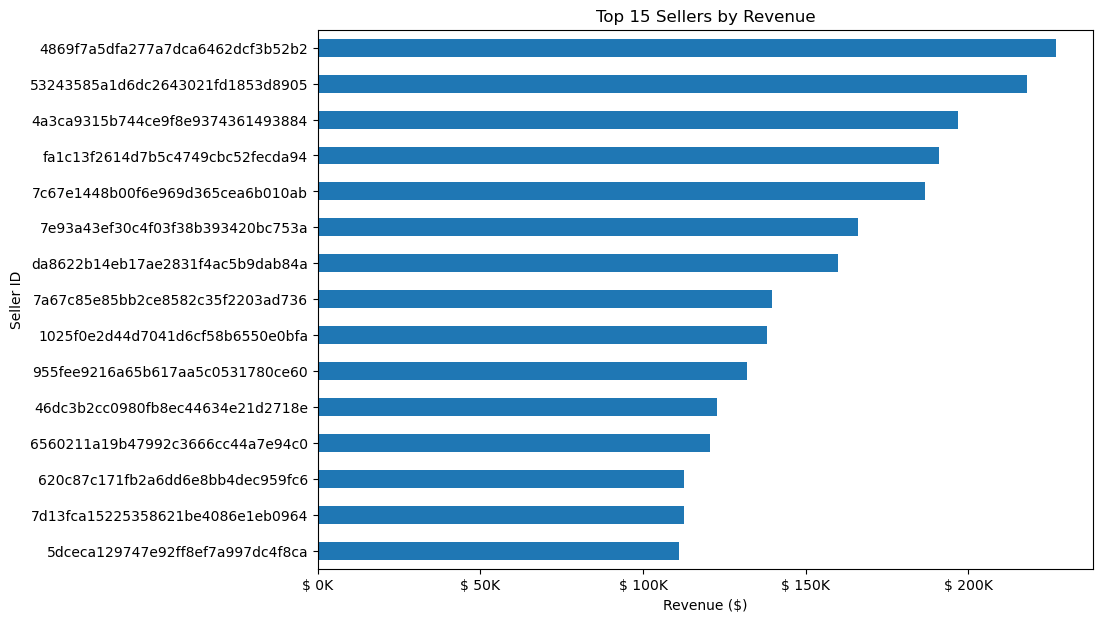

In [35]:
# Top sellers by Revenue
top_sellers = seller_performance.head(15).sort_values("revenue")

top_sellers["revenue"].plot(kind="barh", figsize=(10, 7))

plt.title("Top 15 Sellers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Seller ID")

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"$ {x/1000:.0f}K"))

plt.show()

In [36]:
# Top sellers by Volume
top_volume_sellers = (seller_performance.sort_values("items_sold", ascending=False).head(15))
top_volume_sellers

,revenue,items_sold,orders
seller_id,,,
6560211a19b47992c3666cc44a7e94c0,120702.83,1996,1819
4a3ca9315b744ce9f8e9374361493884,196882.12,1949,1772
1f50f920176fa81dab994f9023523100,106655.71,1926,1399
cc419e0650a3c5ba77189a1882b7556a,101090.96,1719,1651
da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1548,1311
955fee9216a65b617aa5c0531780ce60,131836.71,1472,1261
1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,1420,910
7c67e1448b00f6e969d365cea6b010ab,186570.05,1355,973
ea8482cd71df3c1969d7b9473ff13abc,36696.76,1188,1132


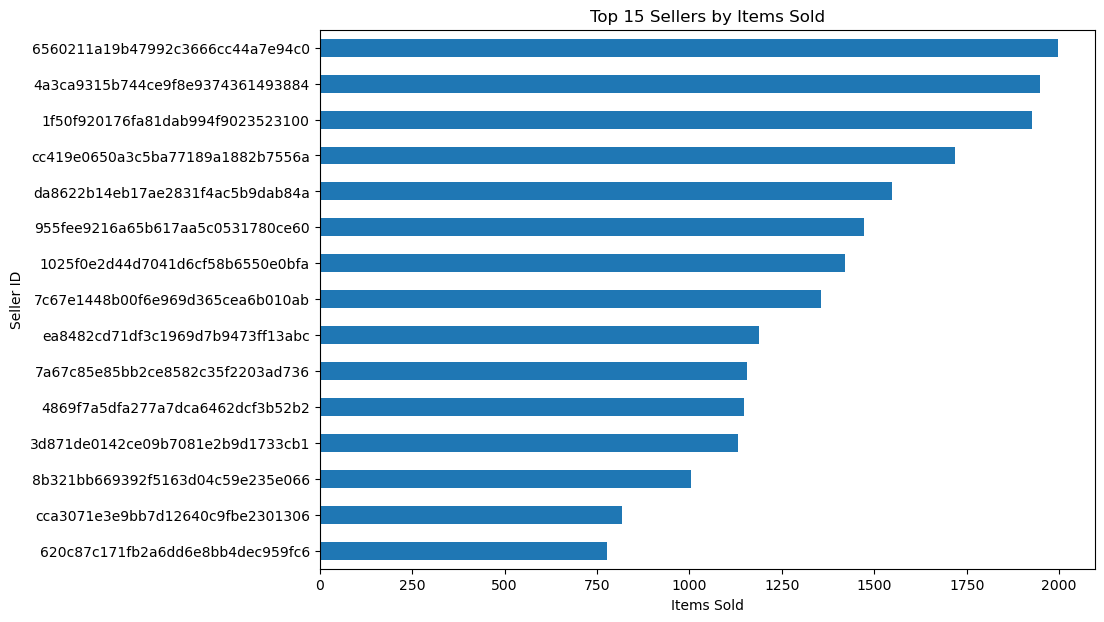

In [37]:
top_volume_sellers.sort_values("items_sold")["items_sold"].plot(kind="barh", figsize=(10, 7))

plt.title("Top 15 Sellers by Items Sold")
plt.xlabel("Items Sold")
plt.ylabel("Seller ID")

plt.show()

In [38]:
# Seller Average Order Value
seller_performance["revenue_per_order"] = (seller_performance["revenue"] / seller_performance["orders"])
seller_performance.sort_values("revenue_per_order", ascending=False).head(15)

,revenue,items_sold,orders,revenue_per_order
seller_id,,,,
e3b4998c7a498169dc7bce44e6bb6277,6735.00,1,1,6735.000000
80ceebb4ee9b31afb6c6a916a574a1e2,6729.00,1,1,6729.000000
ee27a8f15b1dded4d213a468ba4eb391,6499.00,1,1,6499.000000
b37c4c02bda3161a7546a4e6d222d5b2,24075.00,15,4,6018.750000
585175ec331ea177fa47199e39a6170a,3549.00,1,1,3549.000000
abe021b01ba992245271b9aa422032df,6720.00,2,2,3360.000000
a00824eb9093d40e589b940ec45c4eb0,9399.97,3,3,3133.323333
e2a1ac9bf33e5549a2a4f834e70df2f8,14999.45,5,5,2999.890000
e908c0f3646e8b60375734a350d95d71,2951.00,1,1,2951.000000


In [39]:
seller_aov_analysis = seller_performance[seller_performance["orders"] >= 20].sort_values("revenue_per_order",ascending=False)
seller_aov_analysis.head(15)

,revenue,items_sold,orders,revenue_per_order
seller_id,,,,
2bf6a2c1e71bbd29a4ad64e6d3c3629f,50628.90,31,30,1687.630000
b839e41795b7f3ad94cc2014a52f6796,42829.00,36,33,1297.848485
ba90964cff9b9e0e6f32b23b82465f7b,44212.50,38,38,1163.486842
ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,21940.80,20,20,1097.040000
e882b2a25a10b9c057cc49695f222c19,51057.54,58,57,895.746316
17f51e7198701186712e53a39c564617,48019.00,61,56,857.482143
c72de06d72748d1a0dfb2125be43ba63,17522.00,22,21,834.380952
f62d7bb4a613ec758a03342d46b580b2,24665.00,32,32,770.781250
f9244d45189d3a3605499abddeade7d5,15081.44,20,20,754.072000


In [40]:
# Freight Analysis
seller_freight = (sales_sellers.groupby("seller_id").agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("product_id", "count")
    )
)

seller_freight["freight_percentage"] = (seller_freight["freight"] / seller_freight["revenue"]) * 100

seller_freight.sort_values("freight_percentage", ascending=False).head(15)

,revenue,freight,orders,items_sold,freight_percentage
seller_id,,,,,
3d62f86afa7c73be2628a3be1423f5a0,12.00,42.42,2,2,353.500000
0f94588695d71662beec8d883ffacf09,9.00,18.59,1,1,206.555556
95cca791657aabeff15a07eb152d7841,9.99,18.23,1,1,182.482482
43753b27d77860f1654aa72e251a7878,23.90,42.38,1,1,177.322176
bb7ad8a45c027be8ab075b8e465f8ca0,19.98,32.64,2,2,163.363363
a61cc04793308395a840807104365121,14.63,23.74,1,1,162.269310
f9f68daa2af419d38f745478bcb3da1a,11.20,18.00,1,1,160.714286
344223b2a90784f64136a8a5da012e7f,10.90,16.79,1,1,154.036697
c1d1ebb4745cc43cb6f05e9c8a705c9a,12.50,19.21,1,1,153.680000


In [41]:
# minimum order threshold to avoid tiny sellers distorting the result
seller_freight_filtered = seller_freight[seller_freight["orders"] >= 20].sort_values("freight_percentage", ascending=False)
seller_freight_filtered.head(15)

,revenue,freight,orders,items_sold,freight_percentage
seller_id,,,,,
916748bc99315c2d202898ae58b1617e,369.40,377.11,25,32,102.087168
5c853bb56f70f4d14218944bae111d7a,263.13,251.06,23,24,95.412914
e8f6dc8e6a1dcde89d20e3995c8d90b3,2148.74,2016.80,35,44,93.859657
48efc9d94a9834137efd9ea76b065a38,345.60,320.40,33,34,92.708333
20cb7c2fde3e5bf10f0bbe7394e1c6a9,845.00,780.15,31,50,92.325444
b76dba6c951ab00dc4edf0a1aa88037e,2545.31,2282.03,157,167,89.656270
75fbb52eda0cbc24f479d3b2fbfa8d3e,1094.19,900.26,38,41,82.276387
128639473a139ac0f3e5f5ade55873a5,11795.85,9679.69,527,554,82.060131
113e3a788b935f48aad63e1c41dac1bd,847.35,686.60,39,48,81.029091


In [42]:
# Seller State Analysis
seller_state_performance = (sales_sellers.groupby("seller_state").agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("product_id", "count"),
        freight=("freight_value", "sum")
    ).sort_values("revenue", ascending=False)
)

seller_state_performance

,revenue,orders,items_sold,freight
seller_state,,,,
SP,8509511.46,68641,78604,1447545.45
PR,1232096.99,7512,8487,192064.26
MG,977866.31,7735,8603,206561.23
RJ,820611.59,4227,4685,91307.08
SC,613591.65,3603,4000,104147.72
RS,373412.08,1962,2169,56337.01
BA,277925.51,550,624,19221.42
DF,94840.31,808,883,18052.47
PE,91164.15,403,445,12321.95


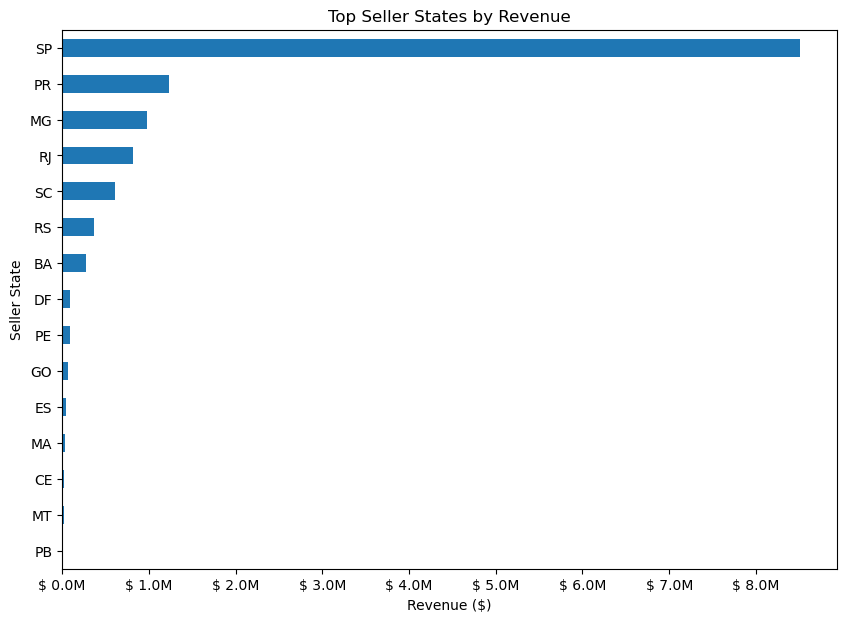

In [43]:
seller_state_performance.head(15)["revenue"].sort_values().plot(kind="barh",figsize=(10, 7))

plt.title("Top Seller States by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Seller State")
plt.gca().xaxis.set_major_formatter( ticker.FuncFormatter(lambda x, pos: f"$ {x/1_000_000:.1f}M"))

plt.show()

# Operations Analysis

In [44]:
delivered_orders = orders[ orders["order_status"] == "delivered"].copy()

In [45]:
# Calculate delivery time
delivered_orders["delivery_days"] = (delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]).dt.total_seconds() / (60 * 60 * 24)

In [46]:
delivered_orders["delivery_days"].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

In [47]:
average_delivery_days = delivered_orders["delivery_days"].mean()
median_delivery_days = delivered_orders["delivery_days"].median()

print(f"Average delivery time: {average_delivery_days:.2f} days")
print(f"Median delivery time: {median_delivery_days:.2f} days")

Average delivery time: 12.56 days
Median delivery time: 10.22 days


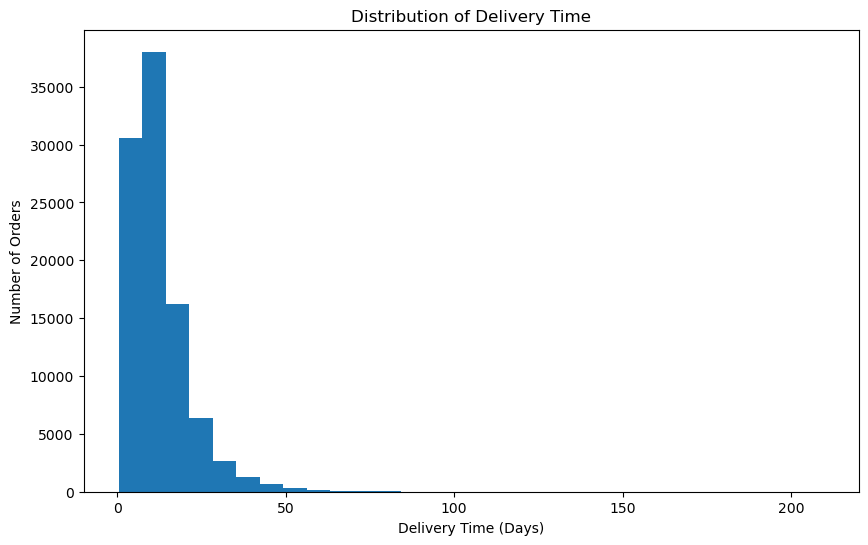

In [48]:
# delivery-time distribution
plt.figure(figsize=(10, 6))

plt.hist(delivered_orders["delivery_days"], bins=30)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

In [49]:
# finding unusually long deliveries
delivered_orders["delivery_days"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
90%         23.096377
95%         29.274046
99%         46.050262
max        209.628611
Name: delivery_days, dtype: float64

In [50]:
# Late delivery rate
delivered_orders["is_late"] = (delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"])

late_delivery_rate = delivered_orders["is_late"].mean() * 100

print(f"Late delivery rate: {late_delivery_rate:.2f}%")

Late delivery rate: 8.11%


In [51]:
delivery_performance = (delivered_orders.groupby("is_late")["delivery_days"].agg(["count", "mean", "median"]))

delivery_performance

,count,mean,median
is_late,,,
False,88644,10.88426,9.727442
True,7826,31.51889,29.154659


In [52]:
# Delivery performance by customer state
delivery_customer = delivered_orders.merge( customers[["customer_id", "customer_state"]], on="customer_id", how="left")

In [53]:
state_delivery = (delivery_customer.groupby("customer_state").agg(
        orders=("order_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        late_rate=("is_late", "mean")
    )
)

state_delivery["late_rate"] = (state_delivery["late_rate"] * 100)

state_delivery = state_delivery.sort_values("late_rate", ascending=False)

state_delivery

,orders,avg_delivery_days,median_delivery_days,late_rate
customer_state,,,,
AL,397,24.543855,22.332917,23.929471
MA,717,21.572976,19.190602,19.665272
PI,476,19.457098,16.292269,15.966387
CE,1279,21.266579,18.209201,15.324472
SE,335,21.519788,18.014306,15.223881
BA,3256,19.335466,16.913964,14.035627
RJ,12350,15.309438,12.041644,13.473684
TO,274,17.658063,15.865885,12.773723
PA,946,23.772917,21.078391,12.367865


In [54]:
# Filtering states with few orders. 
#This prevents a state with, say, 5 orders from appearing as the "worst-performing state" because of a couple of late deliveries.
state_delivery_filtered = state_delivery[state_delivery["orders"] >= 100].sort_values("late_rate", ascending=False)
state_delivery_filtered

,orders,avg_delivery_days,median_delivery_days,late_rate
customer_state,,,,
AL,397,24.543855,22.332917,23.929471
MA,717,21.572976,19.190602,19.665272
PI,476,19.457098,16.292269,15.966387
CE,1279,21.266579,18.209201,15.324472
SE,335,21.519788,18.014306,15.223881
BA,3256,19.335466,16.913964,14.035627
RJ,12350,15.309438,12.041644,13.473684
TO,274,17.658063,15.865885,12.773723
PA,946,23.772917,21.078391,12.367865


- The overall late-delivery rate is 8.11%, but performance varies substantially by state.
| State  | Orders | Avg delivery |  Late rate |
| ------ | -----: | -----------: | ---------: |
| **AL** |    397 |   24.54 days | **23.93%** |
| **MA** |    717 |   21.57 days | **19.67%** |
| **PI** |    476 |   19.46 days | **15.97%** |
| **CE** |  1,279 |   21.27 days | **15.32%** |
| **SE** |    335 |   21.52 days | **15.22%** |
| **BA** |  3,256 |   19.34 days | **14.04%** |

- There is also a very clear contrast with the large states: SP: 5.89% late, 8.76-day average, MG: 5.61% late, 12.01-day average, PR: 5.00% late, 11.99-day average.
- There appears to be a geographical delivery-performance difference. States such as AL, MA, PI and CE have substantially longer delivery times and higher late rates, while SP, MG and PR perform considerably better.

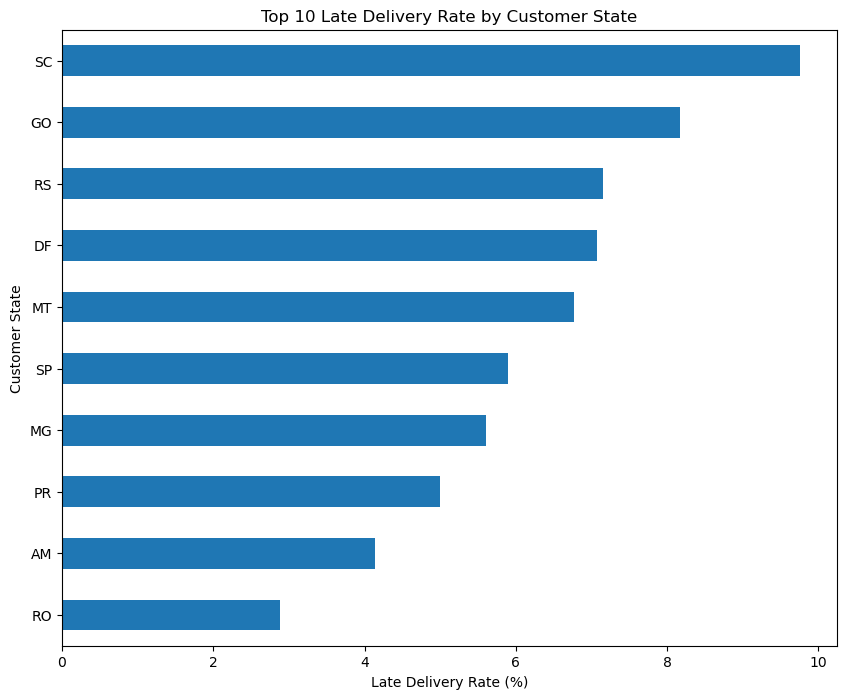

In [55]:
# Late Delivery Rate by State
state_late = (state_delivery_filtered.sort_values("late_rate")).head(10)

state_late["late_rate"].plot(kind="barh",figsize=(10, 8))

plt.title("Top 10 Late Delivery Rate by Customer State")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.show()

In [56]:
# Delivery Performance by Month
monthly_delivery = (delivered_orders.groupby(delivered_orders["order_purchase_timestamp"].dt.to_period("M")).agg(
        orders=("order_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        late_rate=("is_late", "mean")
    )
)
monthly_delivery["late_rate"] = (monthly_delivery["late_rate"] * 100)

monthly_delivery.head()

,orders,avg_delivery_days,late_rate
order_purchase_timestamp,,,
2016-09,1,54.813194,100.000000
2016-10,265,19.600559,1.132075
2016-12,1,4.693021,0.000000
2017-01,750,12.647044,3.066667
2017-02,1653,13.168825,3.206292


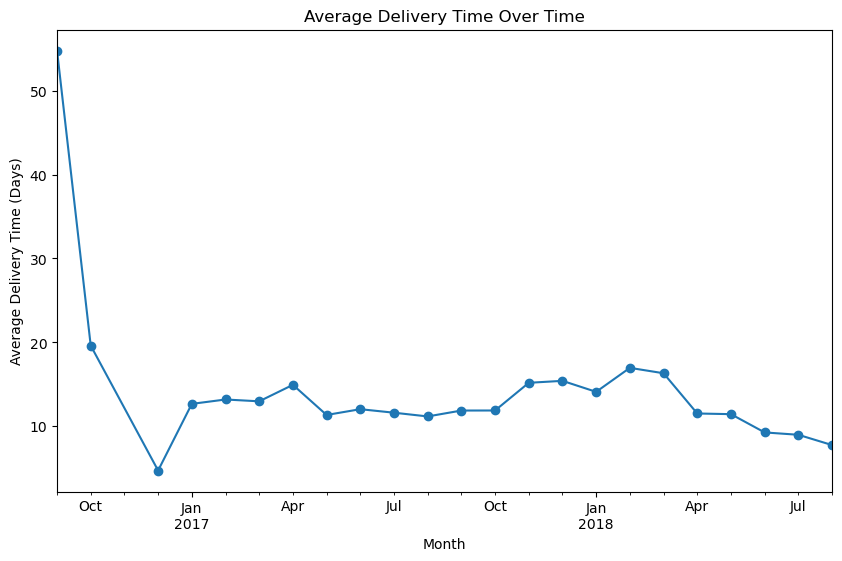

In [57]:
# Average Delivery Time Over Time
monthly_delivery["avg_delivery_days"].plot(figsize=(10, 6), marker="o")

plt.title("Average Delivery Time Over Time")
plt.xlabel("Month")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

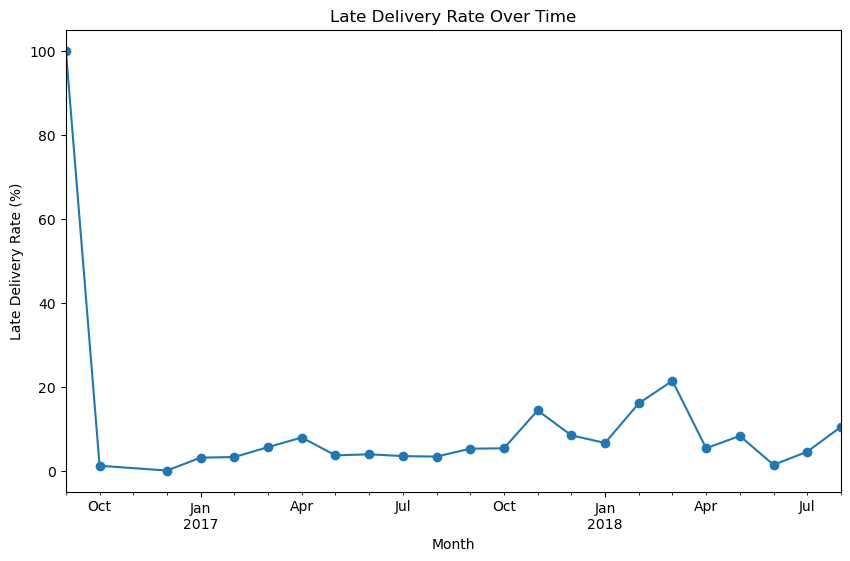

In [58]:
# Late Delivery Rate Over Time
monthly_delivery["late_rate"].plot(figsize=(10, 6), marker="o")

plt.title("Late Delivery Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate (%)")

plt.show()

# Customer Experience

In [59]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [60]:
average_review_score = reviews["review_score"].mean()
print(f"Average review score: {average_review_score:.2f} / 5")

Average review score: 4.09 / 5


In [61]:
delivery_reviews = delivered_orders[ ["order_id", "delivery_days", "is_late" ] ].merge( 
    reviews[["order_id","review_score"]], on="order_id", how="inner")

delivery_reviews.head()

,order_id,delivery_days,is_late,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,False,4
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,False,4
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,False,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,False,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,False,5


In [62]:
# review scores for late vs on-time deliveries
review_by_delivery = (delivery_reviews.groupby("is_late")["review_score"].agg(count="count", average_score="mean"))
review_by_delivery

,count,average_score
is_late,,
False,88661,4.293737
True,7700,2.566494


**Key Findings:**
| Delivery status | Orders with reviews | Average review |
| --------------- | ------------------: | -------------: |
| On time         |              88,661 |   **4.29 / 5** |
| Late            |               7,700 |   **2.57 / 5** |

Late deliveries are strongly associated with lower customer review scores. Orders delivered on time received an average review score of 4.29, compared with 2.57 for late deliveries, a difference of approximately 1.73 points. This indicates that delivery performance is an important factor associated with customer satisfaction. 

In [63]:
# Review Score Distribution
review_distribution = (delivery_reviews.groupby(["is_late", "review_score"]).size().reset_index(name="count"))
review_distribution

,is_late,review_score,count
0,False,1,5852
1,False,2,2335
2,False,3,7086
3,False,4,18033
4,False,5,55355
5,True,1,3554
6,True,2,606
7,True,3,875
8,True,4,954
9,True,5,1711


In [64]:
review_distribution["percentage"] = (review_distribution.groupby("is_late")["count"].transform(lambda x: x / x.sum() * 100))
review_distribution

,is_late,review_score,count,percentage
0,False,1,5852,6.600422
1,False,2,2335,2.633627
2,False,3,7086,7.992240
3,False,4,18033,20.339270
4,False,5,55355,62.434441
5,True,1,3554,46.155844
6,True,2,606,7.870130
7,True,3,875,11.363636
8,True,4,954,12.389610
9,True,5,1711,22.220779


In [66]:
# Low-Rating Rate
delivery_reviews["low_rating"] = (delivery_reviews["review_score"] <= 2)

low_rating_by_delivery = (delivery_reviews.groupby("is_late")["low_rating"].mean() * 100)

low_rating_by_delivery

is_late
False     9.234049
True     54.025974
Name: low_rating, dtype: float64

In [69]:
# Order status 
order_status_summary = (orders["order_status"].value_counts().reset_index())

order_status_summary.columns = ["order_status", "orders"]

order_status_summary

,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [70]:
order_status_summary["percentage"] = (order_status_summary["orders"] / order_status_summary["orders"].sum() ) * 100
order_status_summary

,order_status,orders,percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


In [72]:
# Cancellation Analysis
canceled_orders = orders[orders["order_status"] == "canceled"].copy()
print("Canceled orders:", len(canceled_orders))

cancellation_rate = (len(canceled_orders) /len(orders)) * 100
print(f"Cancellation rate: {cancellation_rate:.2f}%")

Canceled orders: 625
Cancellation rate: 0.63%


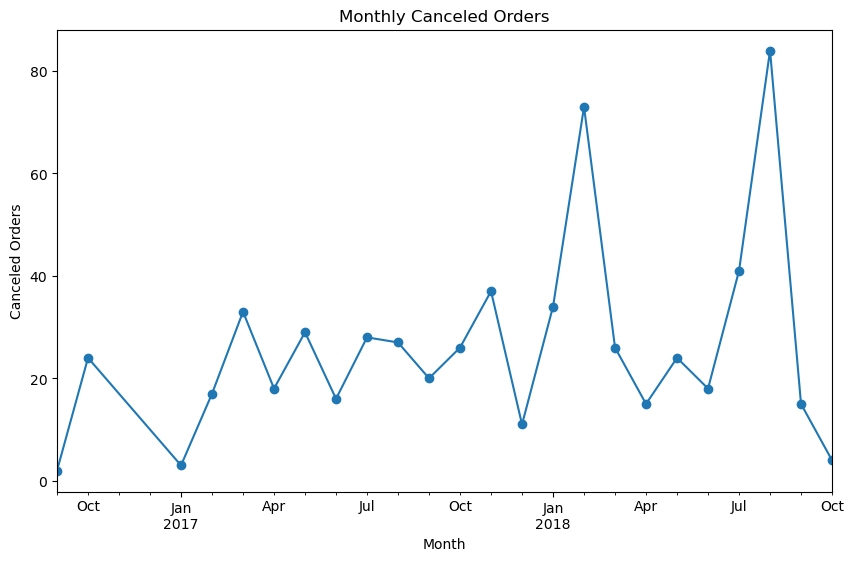

In [73]:
monthly_cancellations = (canceled_orders.groupby(canceled_orders["order_purchase_timestamp"].dt.to_period("M")).size() )

monthly_cancellations.plot(figsize=(10, 6), marker="o" )

plt.title("Monthly Canceled Orders")
plt.xlabel("Month")
plt.ylabel("Canceled Orders")

plt.show()